# Figure 2: HNC on RNNs trained on the 3-bit flip-flop task

This notebook draws every panel of Fig. 2 from the walks in `data/fig2/walks`: from each of five trained
anchors (seeds 0-4), three undirected, three CKA-steered and three DSA-steered walks and one undirected walk
along the flattest direction, plus three walks from anchor 0 steered away from an earlier endpoint (used in
panel F). 
Everything runs on a CPU in a few minutes. The DSA distances of panel B take hours to fit, so they are read
from `data/fig2/dsa_distances.npz` (recompute them with `scripts/fig2_dsa.py`).

To draw the figure from your own walks, run `scripts/run_fig2_walks.sh` and point `WALKS` and `DSA` below
at its output.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from sklearn.manifold import MDS

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from hnc.tasks import flipflop as F
from hnc.metrics import linear_cka
from figstyle import setup, row, panel, legend_above, legend_outside, finish, ref_line, PAL, MUTED, STATE8, LS, TEXT_W
setup()

WALKS = ROOT / 'data' / 'fig2' / 'walks'
DSA = ROOT / 'data' / 'fig2' / 'dsa_distances.npz'
walks = {p.stem: torch.load(p, weights_only=False) for p in sorted(WALKS.glob('*.pt'))}
dsa_table = np.load(DSA)
trained = {s: F.load_anchor(s) for s in range(50)}    # seeds 0-4 are the anchors
print(f'{len(walks)} walks')

53 walks


In [2]:
# walk files are named a<anchor>_<arm>[_k<replicate>]
ARM = {'undirected': 'undirected', 'flattest': 'undirected', 'cka': 'CKA-steered', 'dsa': 'DSA-steered',
       'ckarep': 'CKA-steered', 'ckaxrep': 'CKA-steered', 'dsarep': 'DSA-steered'}
COL = {'anchor': PAL['anchor'], 'undirected': PAL['undirected'], 'CKA-steered': PAL['cka'],
       'DSA-steered': PAL['dsa'], 'trained seeds': PAL['seed']}
anchor_of = lambda tag: int(tag.split('_')[0][1:])
arm_of = lambda tag: ARM[tag.split('_')[1]]

# the checkpoints analysed in the paper: these steps, when saved, and the endpoint
CHECKPOINTS = [25, 50, 100, 150, 200, 300, 400, 500, 600, 800, 1000, 1200, 1400]

def checkpoints(tag):
    s = walks[tag]['snapshot_steps']
    return [int(t) for t in s if t in CHECKPOINTS or t == s[-1]]

def weights(tag, step=None):
    # weights at a saved step: None is the endpoint, otherwise the nearest saved step
    w = walks[tag]
    i = -1 if step is None else int(np.abs(np.asarray(w['snapshot_steps']) - step).argmin())
    return w['snapshots'][i].double()

x, y = (t.double() for t in F.make_data(trials=128, time=50))   # the batch the walks preserve
probe = x[:32]                                                  # CKA and DSA are measured on these trials
x_long = F.make_data()[0].double()                              # 256 trials of 100 steps for the portraits

def hidden(theta, inputs=probe):
    with torch.no_grad():
        return F.forward(theta, inputs, hidden=True)[1]

def cka_distance(a, b):
    return 1 - linear_cka(hidden(a).reshape(-1, 64), hidden(b).reshape(-1, 64)).item()

def portrait(ax, theta, fp_size=60, fp_lw=1.2, n_traj=6):
    # hidden-state trajectories in the network's top three PCs, coloured by output state, and the
    # stable fixed points as diamonds; returns the number of stable fixed points
    H = hidden(theta, x_long).numpy()
    mean = H.reshape(-1, 64).mean(0)
    pcs = np.linalg.svd(H.reshape(-1, 64) - mean, full_matrices=False)[2][:3]
    p = F.unpack(theta)
    state = ((H @ p['fc_out.weight'].numpy().T + p['fc_out.bias'].numpy() > 0) * [1, 2, 4]).sum(-1)
    for i in range(n_traj):
        z = (H[i] - mean) @ pcs.T
        ax.add_collection3d(Line3DCollection(np.stack([z[:-1], z[1:]], 1), colors=[STATE8[s] for s in state[i, :-1]],
                                             lw=0.9, alpha=0.4))
    z = (H[:n_traj].reshape(-1, 64) - mean) @ pcs.T
    ax.auto_scale_xyz(z[:, 0], z[:, 1], z[:, 2])
    stable = [h for h, s in F.fixed_points(theta) if s]
    for h in stable:
        q = (h - mean) @ pcs.T
        ax.scatter([q[0]], [q[1]], [q[2]], s=fp_size, marker='D', c=MUTED['ink'], edgecolors='white',
                   linewidths=fp_lw, depthshade=False, zorder=10)
    ax.grid(False)
    ax.set_axis_off()
    return len(stable)

## A. The task and the anchor's solution

Left: one input channel of one trial and the anchor's output, which holds the sign of the last pulse.
Right: the anchor's hidden-state trajectories in its top three principal components, coloured by the output
state; the eight stable fixed points sit at the corners of a cube.

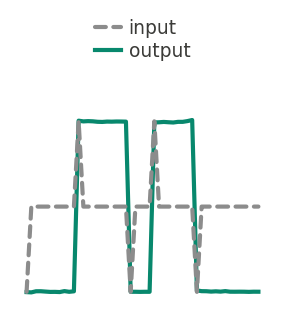

In [3]:
tr, ch = 2, 0                               # the trial and channel shown in A and C
fig, ax = panel(w=2, h=1.7)
ax.plot(x[tr, :, ch], color='0.55', label='input', dashes=(2.6, 1.8), dash_capstyle='round', zorder=3)
ax.plot(F.forward(trained[0], x)[tr, :, ch], color=PAL['anchor'], label='output', zorder=2)
ax.axis('off')
legend_above(fig, ax, ncol=1)
finish(fig)
plt.show()

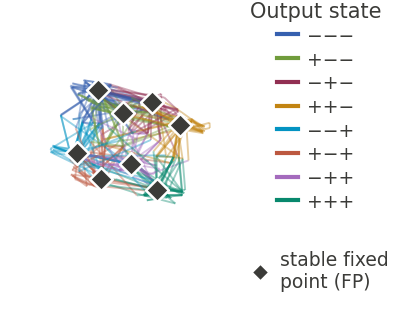

anchor 0: 8 stable fixed points


In [4]:
fig = plt.figure(figsize=(2.9, 2.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.5], wspace=0.05)
ax = fig.add_subplot(gs[0, 0], projection='3d')
ax.computed_zorder = False
n_fp = portrait(ax, trained[0])
ax.set_box_aspect(None, zoom=1.25)

leg = fig.add_subplot(gs[0, 1])
leg.axis('off')
states = [''.join('+' if (s >> b) & 1 else '−' for b in range(3)) for s in range(8)]
leg.add_artist(leg.legend([Line2D([], [], color=c, lw=2) for c in STATE8], states, loc='upper left',
                          bbox_to_anchor=(0, 1.08), title='Output state', handlelength=1.1, handletextpad=0.5))
leg.legend([Line2D([], [], ls='none', marker='D', ms=6, mfc=MUTED['ink'], mec='white', mew=1.2)],
           ['stable fixed\npoint (FP)'], loc='lower left', bbox_to_anchor=(0, -0.12), handlelength=1.1, handletextpad=0.5)
finish(fig)
plt.show()
print(f'anchor 0: {n_fp} stable fixed points')

## B. What the walks change, and at what cost

All walks from anchor 0. Left: the task loss along each walk, which every walk keeps below the ceiling.
Middle and right: CKA and DSA distance to the anchor against the weight movement, at three checkpoints
(about a quarter, half and three quarters of the way) and the endpoint. Grey: pairs of independently trained
networks (seeds 5-14).

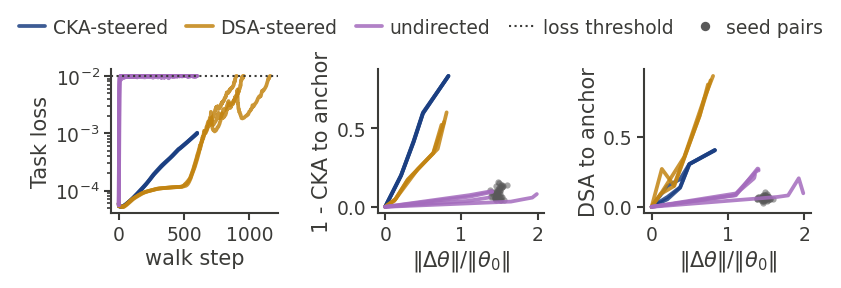

In [5]:
A = 0
theta0 = trained[A]
norm0 = theta0.norm()
tags_B = [t for t in walks if anchor_of(t) == A and t.split('_')[1] in ('undirected', 'flattest', 'cka', 'dsa')]
walk_dsa = {(t, s): d for t, s, d in zip(dsa_table['walk'], dsa_table['step'], dsa_table['dsa'])}
seed_dsa = {(a, b): d for a, b, d in zip(dsa_table['seed_a'], dsa_table['seed_b'], dsa_table['seed_dsa'])}

def four_checkpoints(tag):
    c = checkpoints(tag)
    inner = c[:-1]
    return sorted({inner[round(f * (len(inner) - 1))] for f in (0.25, 0.5, 0.75)}) + [c[-1]]

pairs = [(i, j) for i in range(5, 15) for j in range(i + 1, 15)]
seed_w = [((trained[i] - trained[j]).norm() / norm0).item() for i, j in pairs]
seed_c = [cka_distance(trained[i], trained[j]) for i, j in pairs]
seed_d = [seed_dsa.get(p, np.nan) for p in pairs]

fig, ax = row(3, h=1.7, sharey=False)
ax[1].scatter(seed_w, seed_c, s=9, c='0.35', alpha=0.55, lw=0, zorder=1)
ax[2].scatter(seed_w, seed_d, s=9, c='0.35', alpha=0.55, lw=0, zorder=1)
seen = set()
for t in tags_B:
    arm, style = arm_of(t), dict(color=COL[arm_of(t)], lw=1.8, alpha=0.85, solid_capstyle='round')
    ax[0].plot(walks[t]['loss'], label=None if arm in seen else arm, **style)
    seen.add(arm)
    steps = four_checkpoints(t)
    dist = [0] + [((weights(t, s) - theta0).norm() / norm0).item() for s in steps]
    ax[1].plot(dist, [0] + [cka_distance(theta0, weights(t, s)) for s in steps], **style)
    ax[2].plot(dist, [0] + [walk_dsa.get((t, s), np.nan) for s in steps], **style)
ref_line(ax[0], 1e-2, label='loss threshold')
ax[0].set_yscale('log'); ax[0].set_xticks([0, 500, 1000])
ax[0].set_xlabel('walk step'); ax[0].set_ylabel('Task loss')
for a, lab in zip(ax[1:], ['1 - CKA to anchor', 'DSA to anchor']):
    a.set_xticks([0, 1, 2]); a.set_xlabel(r'$\|\Delta\theta\|/\|\theta_0\|$'); a.set_ylabel(lab)
h, l = ax[0].get_legend_handles_labels()
h.append(Line2D([], [], ls='none', marker='o', ms=4.5, mfc='0.35', mec='none'))
l.append('seed pairs')
fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 0.985), ncol=5, columnspacing=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()

## C. Where the walks end up

The state space of one network per walk type, drawn as in A: the endpoint of the undirected walk along the
flattest direction from anchor 1, the endpoint of a CKA-steered walk, and a DSA-steered walk at step 635.
Below each, the walked network's output (solid) against its anchor's output (dotted) on the trial of A.

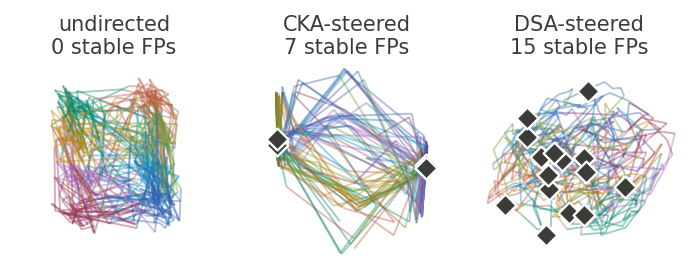

In [6]:
PICK_C = [('undirected', 'a1_flattest', None), ('CKA-steered', 'a0_cka_k0', None), ('DSA-steered', 'a0_dsa_k0', 635)]
theta_C = {tag: weights(tag, step) for _, tag, step in PICK_C}

fig = plt.figure(figsize=(4.65, 1.5))
gs = fig.add_gridspec(1, 3, wspace=0.0, left=0.0, right=1.0, bottom=0.0, top=0.88)
for j, (name, tag, _) in enumerate(PICK_C):
    ax = fig.add_subplot(gs[0, j], projection='3d')
    ax.computed_zorder = False
    n_fp = portrait(ax, theta_C[tag], fp_size=55, fp_lw=1.1)
    ax.set_title(f'{name}\n{n_fp} stable FPs')
    ax.set_box_aspect(None, zoom=1.5)
plt.show()

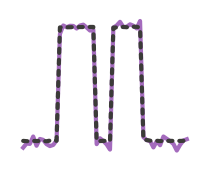

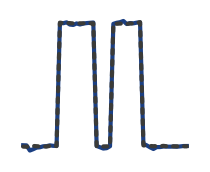

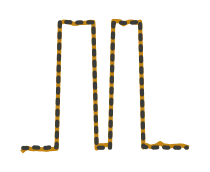

In [7]:
for name, tag, _ in PICK_C:
    fig, ax = panel(w=1.5, h=1.25)
    with torch.no_grad():
        ax.plot(F.forward(theta_C[tag], x)[tr, :, ch], color=COL[name], lw=2, zorder=1)
        ax.plot(F.forward(walks[tag]['theta0'].double(), x)[tr, :, ch], ls=LS['target'], color=PAL['target'],
                lw=2, dash_capstyle='round', zorder=2)
    ax.axis('off')
    finish(fig)
    plt.show()

## D. How the undirected network holds its memories without fixed points

Hidden states of the undirected network of C during 300 steps without input, after an in-distribution
preamble. Left and middle: two trials per remembered state in the top two PCs of the readout subspace (the
row space of the readout weights) and of the readout-null subspace. Right: the per-step movement of the hidden
state within each subspace, for this network and its anchor. The anchor settles on fixed points; the
undirected network keeps moving, almost entirely where the readout cannot see it.

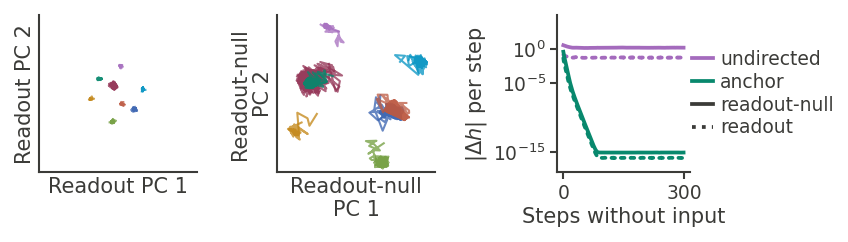

In [8]:
th_u, th_a = theta_C['a1_flattest'], walks['a1_flattest']['theta0'].double()
T_PRE, T_HOLD, NB = 20, 300, 256
rng = np.random.default_rng(0)
pulses = rng.binomial(1, 0.3, (NB, T_PRE, 3)); pulses[:, 0] = 1
pre = pulses * (2 * rng.binomial(1, 0.5, pulses.shape) - 1)
last = np.array([[pre[i, np.nonzero(pre[i, :, b])[0][-1], b] for b in range(3)] for i in range(NB)])
state = ((last > 0) * [1, 2, 4]).sum(1)
stim = torch.zeros(NB, T_PRE + T_HOLD, 3, dtype=torch.float64)
stim[:, :T_PRE] = torch.as_tensor(pre, dtype=torch.float64)
Hh, Hha = (hidden(th, stim)[:, T_PRE:].numpy() for th in (th_u, th_a))
W_out = F.unpack(th_u)['fc_out.weight'].numpy()
V = np.linalg.svd(W_out, full_matrices=False)[2]
P_read = V.T @ V                                  # projector onto the readout row space

X = Hh.reshape(-1, 64) - Hh.reshape(-1, 64).mean(0)
V_read = np.linalg.svd(X @ P_read, full_matrices=False)[2][:2]
V_null = np.linalg.svd(X - X @ P_read, full_matrices=False)[2][:2]
mu = Hh.reshape(-1, 64).mean(0)

FW, FH = 4.3, 1.6
fig = plt.figure(figsize=(FW, FH))
SQ, Y0, SQH = 1.05 / FW, 0.20, 1.05 / FH
ax = [fig.add_axes([0.075, Y0, SQ, SQH]), fig.add_axes([0.075 + SQ + 0.125, Y0, SQ, SQH]),
      fig.add_axes([0.075 + 2 * SQ + 0.315, Y0, 0.205, SQH])]
for s in range(8):
    for t in np.where(state == s)[0][:2]:
        z = Hh[t] - mu
        ax[0].plot(*((z @ P_read) @ V_read.T).T, color=STATE8[s], lw=1.0, alpha=0.75)
        ax[1].plot(*((z - z @ P_read) @ V_null.T).T, color=STATE8[s], lw=1.0, alpha=0.75)
lim = 1.05 * max(np.abs(X @ P_read @ V_read.T).max(), np.abs((X - X @ P_read) @ V_null.T).max())
for a, name in zip(ax[:2], ['Readout ', 'Readout-null\n']):
    a.set_xlabel(name + 'PC 1'); a.set_ylabel(name + 'PC 2')
    a.set_xticks([]); a.set_yticks([])
    a.set_xlim(-lim, lim); a.set_ylim(-lim, lim); a.set_aspect('equal', adjustable='box')
for H, lab, c in [(Hh, 'undirected', PAL['undirected']), (Hha, 'anchor', PAL['anchor'])]:
    d = np.diff(H, axis=1)
    ax[2].plot(np.linalg.norm(d - d @ P_read, axis=-1).mean(0), color=c, ls='-', lw=1.8, label=lab)
    ax[2].plot(np.linalg.norm(d @ P_read, axis=-1).mean(0), color=c, ls=':', lw=1.8, dash_capstyle='round')
ax[2].set_yscale('log'); ax[2].set_xlabel('Steps without input'); ax[2].set_ylabel(r'$|\Delta h|$ per step')
ax[2].set_xticks([0, 300]); ax[2].set_ylim(1e-18, 1e5); ax[2].set_yticks([1e-15, 1e-5, 1e0])
h, l = ax[2].get_legend_handles_labels()
ls_keys = [Line2D([], [], color=MUTED['ink'], ls=s, lw=1.8) for s in ('-', ':')]
ax[2].legend(h + ls_keys, l + ['readout-null', 'readout'], loc='center left', bbox_to_anchor=(0.99, 0.5),
             handlelength=1.1, handletextpad=0.4, labelspacing=0.2, borderpad=0.0)
plt.show()

## E. Memory and robustness beyond the trained conditions

Left: after an in-distribution preamble the input is switched off for 2,000 steps; the fraction of 256 trials
whose output still equals the last commanded state. Right: after 50 silent steps the hidden state is displaced
by a random vector of the given norm (10 directions per trial), and the fraction of trials that return to the
commanded state within 300 steps. Thick lines: the networks of C and anchor 0. Thin lines: the other anchors
and one endpoint per anchor of other walks of each type.

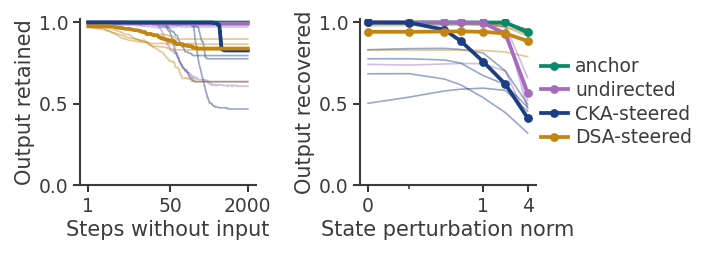

In [9]:
# walk type -> networks; the first one is drawn thick
E_NETS = {'anchor': [f'anchor{a}' for a in range(5)],
          'undirected': ['a1_flattest', 'a0_flattest', 'a2_flattest', 'a3_flattest', 'a4_flattest'],
          'CKA-steered': ['a0_cka_k0', 'a1_cka_k0', 'a2_cka_k0', 'a3_cka_k0', 'a4_cka_k0'],
          'DSA-steered': ['a0_dsa_k0', 'a1_dsa_k0', 'a2_dsa_k0', 'a4_dsa_k0', 'a0_dsa_k1']}
T_PRE, T_HOLD, NB = 20, 2000, 256
rng = np.random.default_rng(0)
pulses = rng.binomial(1, 0.3, (NB, T_PRE, 3)); pulses[:, 0] = 1
pre = pulses * (2 * rng.binomial(1, 0.5, pulses.shape) - 1)
target = torch.as_tensor(np.array([[pre[i, np.nonzero(pre[i, :, b])[0][-1], b] for b in range(3)] for i in range(NB)]) > 0)
x_ood = torch.zeros(NB, T_PRE + T_HOLD, 3, dtype=torch.float64)
x_ood[:, :T_PRE] = torch.as_tensor(pre, dtype=torch.float64)
EPS, T_SETTLE, T_REC, NK = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0], 50, 300, 10

@torch.no_grad()
def ood_probes(theta):
    out, H = F.forward(theta, x_ood, hidden=True)
    retained = ((out[:, T_PRE:] > 0) == target[:, None]).all(-1).double().mean(0).numpy()
    p = F.unpack(theta)
    W, b = p['recurrent.weight_hh_l0'], p['recurrent.bias_ih_l0'] + p['recurrent.bias_hh_l0']
    readout = lambda h: h @ p['fc_out.weight'].T + p['fc_out.bias'] > 0
    h0 = H[:, T_PRE + T_SETTLE - 1]
    keep = (readout(h0) == target).all(-1)               # trials still correct before the kick
    h0, tk = h0[keep], target[keep]
    gen, recovered = torch.Generator().manual_seed(1), []
    for eps in EPS:
        d = torch.randn(NK, h0.shape[0], 64, dtype=torch.float64, generator=gen)
        h = (h0[None] + eps * d / d.norm(dim=-1, keepdim=True)).reshape(-1, 64)
        for _ in range(T_REC):
            h = torch.tanh(b + h @ W.T)
        recovered.append((readout(h) == tk.repeat(NK, 1)).all(-1).double().mean().item())
    return retained, np.array(recovered)

E_NETS = {arm: [n for n in names if n.startswith('anchor') or n in walks] for arm, names in E_NETS.items()}
nets = lambda name: trained[int(name[6:])] if name.startswith('anchor') else weights(name)
probes = {n: ood_probes(nets(n)) for names in E_NETS.values() for n in names}

fig, ax = row(2, width=TEXT_W, h=1.8, sharey=False)
for arm, names in E_NETS.items():
    for i, n in enumerate(names):
        retained, recovered = probes[n]
        thick = dict(lw=1.8, zorder=5) if i == 0 else dict(lw=0.8, alpha=0.45)
        ax[0].plot(np.arange(1, T_HOLD + 1), retained, color=COL[arm], **thick)
        ax[1].plot(EPS, recovered, color=COL[arm], **thick, **(dict(marker='o', ms=3, label=arm) if i == 0 else {}))
ax[0].set_xscale('log'); ax[0].set_xticks([1, 50, 2000], ['1', '50', '2000'])
ax[1].set_xscale('symlog', linthresh=0.1, linscale=0.5); ax[1].set_xticks([0, 1, 4], ['0', '1', '4'])
for a in ax:
    a.set_ylim(0, 1.02); a.set_yticks([0, 0.5, 1.0])
ax[0].set_xlabel('Steps without input'); ax[0].set_ylabel('Output retained')
ax[1].set_xlabel('State perturbation norm'); ax[1].set_ylabel('Output recovered')
legend_outside(ax[1])
finish(fig)
ax[1].get_legend().set_bbox_to_anchor((0.99, 0.5), transform=ax[1].transAxes)
fig.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

## F. The solutions reachable from one anchor

Metric MDS of 131 networks: anchor 0, every checkpoint of its undirected, CKA-steered and DSA-steered walks
(including the three walks steered away from an earlier endpoint, coloured by the metric they steer), and ten
independently trained networks, using pairwise CKA distance (left) or weight distance relative to the anchor's
norm (right). Marker size and opacity grow along each walk.

131 networks; min bit accuracy 0.9993


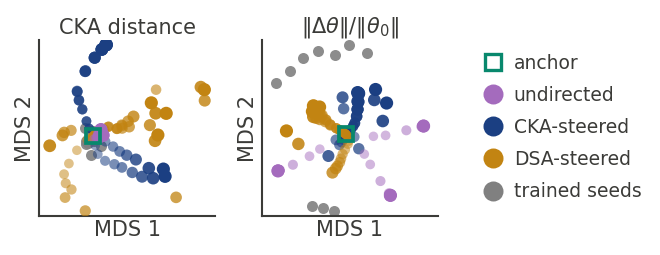

In [10]:
FAMILY = {'undirected': 'undirected', 'cka': 'CKA-steered', 'ckarep': 'CKA-steered', 'ckaxrep': 'CKA-steered',
          'dsa': 'DSA-steered', 'dsarep': 'DSA-steered'}
thetas, fam, frac = [trained[0]], ['anchor'], [0.0]
for t in walks:
    if anchor_of(t) == 0 and t.split('_')[1] in FAMILY:
        c = checkpoints(t)
        thetas += [weights(t, s) for s in c]; fam += [FAMILY[t.split('_')[1]]] * len(c); frac += [s / c[-1] for s in c]
for s in range(1, 11):
    thetas.append(trained[s]); fam.append('trained seeds'); frac.append(0.0)
fam, frac, TH = np.array(fam), np.array(frac), torch.stack(thetas)
print(f'{len(TH)} networks; min bit accuracy {min((torch.sign(F.forward(th, x)) == torch.sign(y)).double().mean().item() for th in TH):.4f}')

Xc = [hidden(th).reshape(-1, 64) for th in TH]
Xc = torch.stack([X - X.mean(0) for X in Xc])
self_norm = torch.stack([(X.T @ X).norm() for X in Xc])
D_cka = np.array([1 - ((X.T @ Xc).pow(2).sum((1, 2)) / (self_norm[i] * self_norm)).numpy() for i, X in enumerate(Xc)])
D_w = (torch.cdist(TH, TH) / TH[0].norm()).numpy()

def mds(D):
    Y = MDS(n_components=2, dissimilarity='precomputed', random_state=0, normalized_stress=False, n_init=4,
            max_iter=600).fit_transform((D + D.T) / 2)
    Y = Y - Y[0]                                               # anchor at the origin
    if Y[(fam == 'CKA-steered') & (frac == 1.0), 0].mean() < 0: Y[:, 0] *= -1
    if Y[(fam == 'DSA-steered') & (frac == 1.0), 1].mean() < 0: Y[:, 1] *= -1
    return Y

fig, ax = row(2, h=2, width=4, sharey=False)
for a, (lab, D) in zip(ax, [('CKA distance', D_cka), (r'$\|\Delta\theta\|/\|\theta_0\|$', D_w)]):
    Y = mds(D)
    m = fam == 'trained seeds'
    a.scatter(Y[m, 0], Y[m, 1], s=28, color=COL['trained seeds'], lw=0, alpha=0.9, zorder=2)
    for f in ['CKA-steered', 'DSA-steered', 'undirected']:
        m = fam == f
        a.scatter(Y[m, 0], Y[m, 1], s=20 + 20 * frac[m], color=COL[f], lw=0, alpha=0.45 + 0.55 * frac[m],
                  zorder=4.5 if f == 'undirected' else 4)
    a.plot(0, 0, 's', mfc='none', mec=COL['anchor'], mew=1.8, ms=7, zorder=6)
    h = 1.06 * max(np.ptp(Y[:, 0]), np.ptp(Y[:, 1])) / 2
    cx, cy = (Y[:, 0].min() + Y[:, 0].max()) / 2, (Y[:, 1].min() + Y[:, 1].max()) / 2
    a.set_xlim(cx - h, cx + h); a.set_ylim(cy - h, cy + h); a.set_aspect('equal', adjustable='box')
    a.set_xticks([]); a.set_yticks([]); a.set_xlabel('MDS 1'); a.set_ylabel('MDS 2'); a.set_title(lab)
finish(fig, rect=[0, 0, 0.78, 1])
keys = [('anchor', True), ('undirected', False), ('CKA-steered', False), ('DSA-steered', False), ('trained seeds', False)]
fig.legend([Line2D([], [], ls='', marker='s' if hollow else 'o', ms=8, mfc='none' if hollow else COL[k], mec=COL[k], mew=1.6)
            for k, hollow in keys], [k for k, _ in keys], loc='center left', bbox_to_anchor=(0.80, 0.5),
           handletextpad=0.4, labelspacing=0.7)
plt.show()